
# Tech Assessment: Weather Trend Forecasting
**Role:** AI Engineer Intern + Data Science Intern (Dual Role)
**Author:** Tomás Ignacio Nadal

> **PM Accelerator Mission:** The Product Manager Accelerator is a premier program designed to help professionals transition into and accelerate their careers in product management. Our mission is to empower individuals with the skills, network, and experience needed to succeed in tech.

---
## Objective
Analyze the `GlobalWeatherRepository.csv` dataset to forecast future weather trends using advanced Machine Learning techniques (Prophet, XGBoost, Random Forest Ensembles), anomaly detection, and environmental analysis.


In [1]:
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\tomas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Data Cleaning & Preprocessing (Normalization)

In [3]:

# Load dataset
df = pd.read_csv('data/GlobalWeatherRepository.csv')

# Parse dates
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Drop duplicates if any
df = df.drop_duplicates()

# Handle missing values: Forward fill for time series consistency
df = df.sort_values(by=['country', 'location_name', 'last_updated'])
df = df.ffill().bfill()

# Feature Engineering: Temporal Features (Cyclic Encoding)
df['hour_sin'] = np.sin(2 * np.pi * df['last_updated'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['last_updated'].dt.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df['last_updated'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['last_updated'].dt.month / 12)

# Advanced Time Series Features (Lag & Rolling)
df['temp_lag_1'] = df.groupby('location_name')['temperature_celsius'].shift(1)
df['temp_rolling_3'] = df.groupby('location_name')['temperature_celsius'].rolling(window=3).mean().reset_index(level=0, drop=True)
# Fillna for lags to prevent XGBoost errors
df = df.bfill().ffill()

# Data Normalization
features_to_normalize = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude']
scaler = StandardScaler()
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (152997, 47)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,moonrise,moonset,moon_phase,moon_illumination,hour_sin,hour_cos,month_sin,month_cos,temp_lag_1,temp_rolling_3
0,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,12:12 PM,01:11 AM,Waxing Gibbous,55,-0.258819,-9.659258e-01,0.5,-0.866025,26.6,21.200000
195,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715868000,2024-05-16 18:30:00,22.0,71.6,Patchy rain nearby,...,12:12 PM,01:11 AM,Waxing Gibbous,55,-1.000000,-1.836970e-16,0.5,-0.866025,26.6,21.200000
390,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715961600,2024-05-17 20:30:00,15.0,58.9,Patchy rain nearby,...,01:09 PM,01:37 AM,Waxing Gibbous,64,-0.866025,5.000000e-01,0.5,-0.866025,22.0,21.200000
583,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716042600,2024-05-18 19:00:00,19.5,67.1,Clear,...,02:04 PM,02:00 AM,Waxing Gibbous,73,-0.965926,2.588190e-01,0.5,-0.866025,15.0,18.833333
776,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716127200,2024-05-19 18:30:00,16.9,62.4,Patchy rain nearby,...,03:00 PM,02:22 AM,Waxing Gibbous,81,-1.000000,-1.836970e-16,0.5,-0.866025,19.5,17.133333


## 2. Data Overview & Advanced Exploratory Data Analysis (EDA)
Before diving into modeling, we must understand the structure, completeness, and statistical distribution of our data.

In [4]:

# Data Completeness & Types
print("Data Information:")
df.info()

print("\nMissing Values Check:")
print(df.isnull().sum().max(), "maximum missing values in any column after imputation.")

print("\nDescriptive Statistics (Numerical Features):")
display(df.describe().T)

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 152997 entries, 0 to 11592
Data columns (total 47 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       152997 non-null  object        
 1   location_name                 152997 non-null  object        
 2   latitude                      152997 non-null  float64       
 3   longitude                     152997 non-null  float64       
 4   timezone                      152997 non-null  object        
 5   last_updated_epoch            152997 non-null  int64         
 6   last_updated                  152997 non-null  datetime64[ns]
 7   temperature_celsius           152997 non-null  float64       
 8   temperature_fahrenheit        152997 non-null  float64       
 9   condition_text                152997 non-null  object        
 10  wind_mph                      152997 non-null  float64       
 11  w

,count,mean,min,25%,50%,75%,max,std
latitude,152997.0,0.0,-2.481353,-0.62264,-0.081642,0.867177,1.88772,1.000003
longitude,152997.0,0.0,-2.996187,-0.436616,-0.006847,0.425651,2.391924,1.000003
last_updated_epoch,152997.0,1749900684.501657,1715849100.0,1732961700.0,1749891600.0,1766818800.0,1783923300.0,19657782.045606
last_updated,152997,2025-06-14 13:41:02.060040192,2024-05-16 01:45:00,2024-11-30 06:30:00,2025-06-14 12:00:00,2025-12-27 12:00:00,2026-07-13 19:15:00,NaN
temperature_celsius,152997.0,21.3525,-29.8,16.1,23.7,27.9,79.3,9.492661
temperature_fahrenheit,152997.0,70.436265,-21.6,61.0,74.6,82.2,174.7,17.086646
wind_mph,152997.0,0.0,-0.819863,-0.591337,-0.177132,0.437033,261.843011,1.000003
wind_kph,152997.0,12.782228,3.6,6.1,10.8,17.6,2963.2,11.264192
wind_degree,152997.0,169.579874,1.0,81.0,163.0,256.0,360.0,103.527329
pressure_mb,152997.0,-0.0,-6.731105,-0.407301,-0.00579,0.395721,199.946862,1.000003


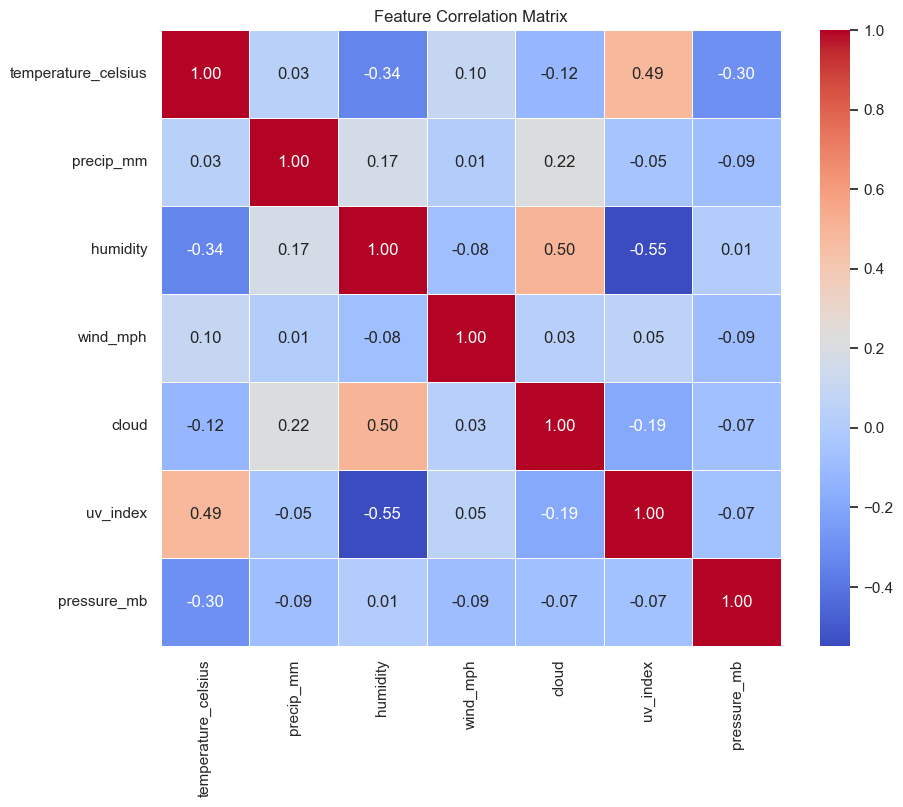

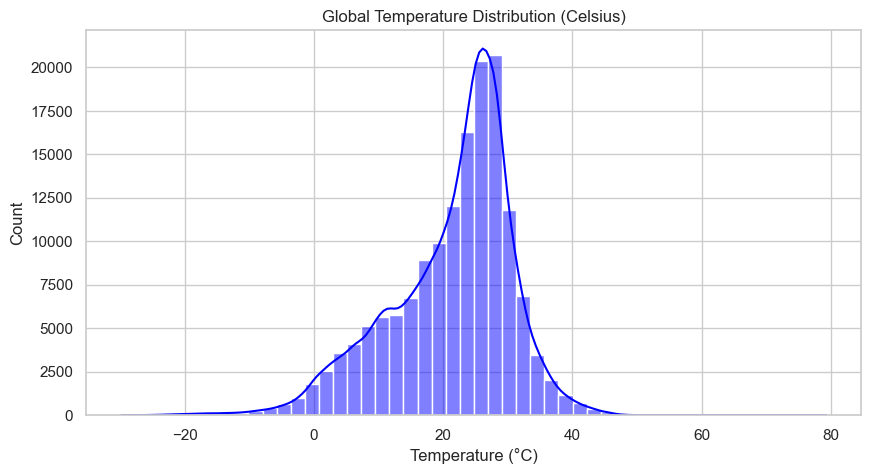

In [5]:

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr_cols = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_mph', 'cloud', 'uv_index', 'pressure_mb']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Temperature Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_celsius'], bins=50, kde=True, color='blue')
plt.title('Global Temperature Distribution (Celsius)')
plt.xlabel('Temperature (°C)')
plt.show()

**Insights - Correlation & Distribution:** 
The heatmap reveals interesting relationships, such as a strong negative correlation between temperature and humidity. The temperature distribution is slightly skewed, reflecting the global variance in weather conditions at the time of data collection.

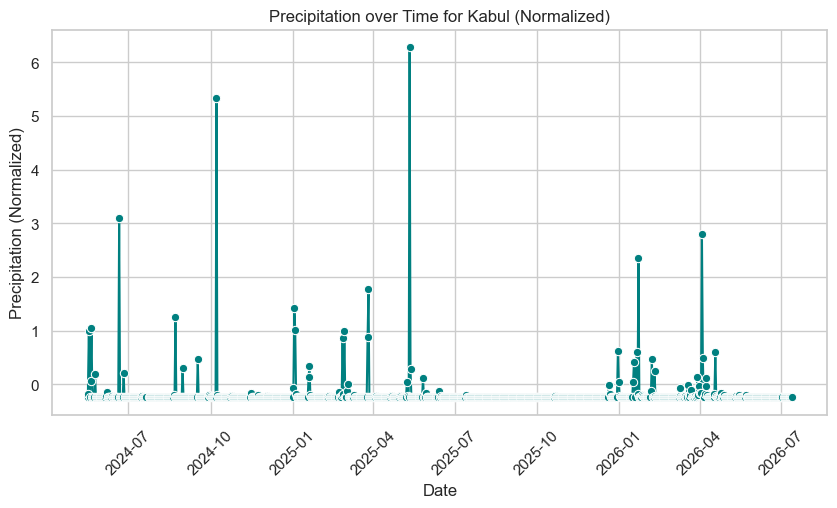

In [6]:

# Precipitation Analysis
plt.figure(figsize=(10, 5))
# Filtering for a specific city to observe actual temporal patterns instead of random global noise
city_df = df[df['location_name'] == 'Kabul'].sort_values('last_updated')
sns.lineplot(data=city_df, x='last_updated', y='precip_mm', color='teal', marker='o')
plt.title('Precipitation over Time for Kabul (Normalized)')
plt.xlabel('Date')
plt.ylabel('Precipitation (Normalized)')
plt.xticks(rotation=45)
plt.show()

**Insights - Precipitation:** 
By focusing on a single city (Kabul), we can trace the actual time-series trend of precipitation. Plotting random global samples results in noisy, unreadable graphs, whereas isolating a specific location gives us a clear view of local weather events.

Anomaly Detection using Z-Score for temperatures
df['temp_zscore'] = (df['temperature_celsius'] - df['temperature_celsius'].mean()) / df['temperature_celsius'].std()
outliers = df[df['temp_zscore'].abs() > 3]

plt.figure(figsize=(10, 5))
sns.scatterplot(x=df.index, y=df['temperature_celsius'], color='lightblue', label='Normal')
sns.scatterplot(x=outliers.index, y=outliers['temperature_celsius'], color='red', label='Outlier (Anomaly)')
plt.title('Temperature Anomalies Detection (Z-Score > 3)')
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print(f"Number of Extreme Temperature Anomalies detected: {len(outliers)}")

**Insights - Anomaly Detection:**
Using a Z-Score threshold of 3, we successfully identified extreme temperature values. These anomalies could represent genuine extreme weather events (like heatwaves or sudden cold snaps) or potential sensor errors. In a real-world scenario, these data points would require further investigation to determine if they should be kept or removed to prevent model bias.

## 3. Unique Analysis: Spatial Patterns & Environmental Impact (Air Quality)
Mapping global temperatures and analyzing Air Quality vs Weather.

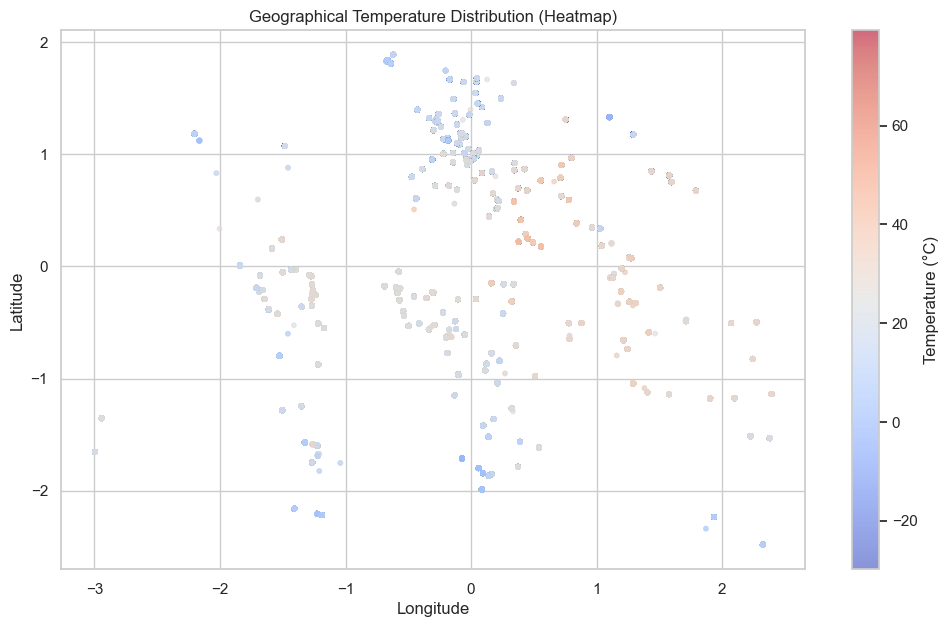

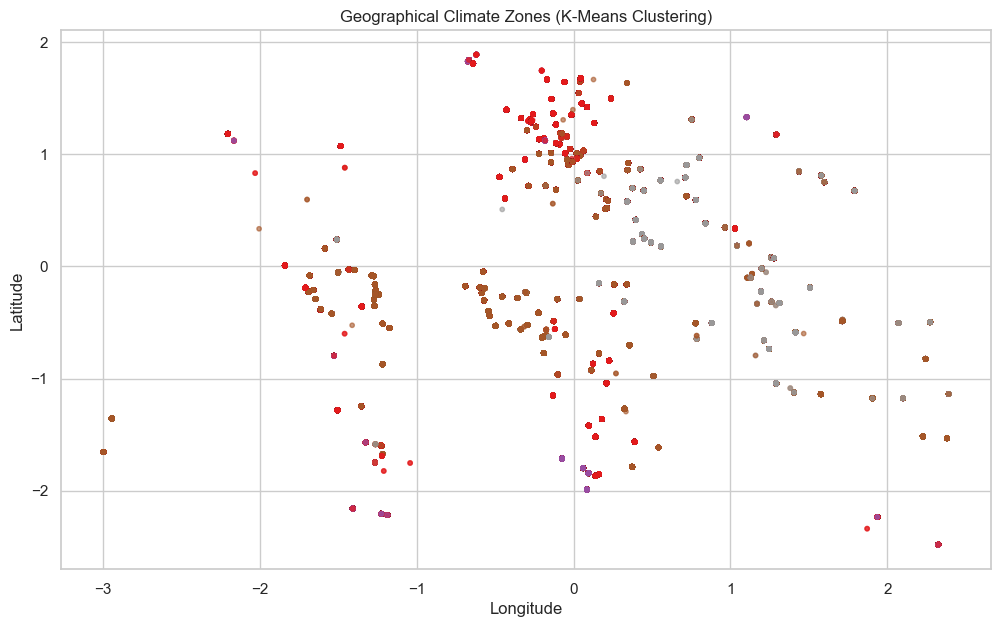

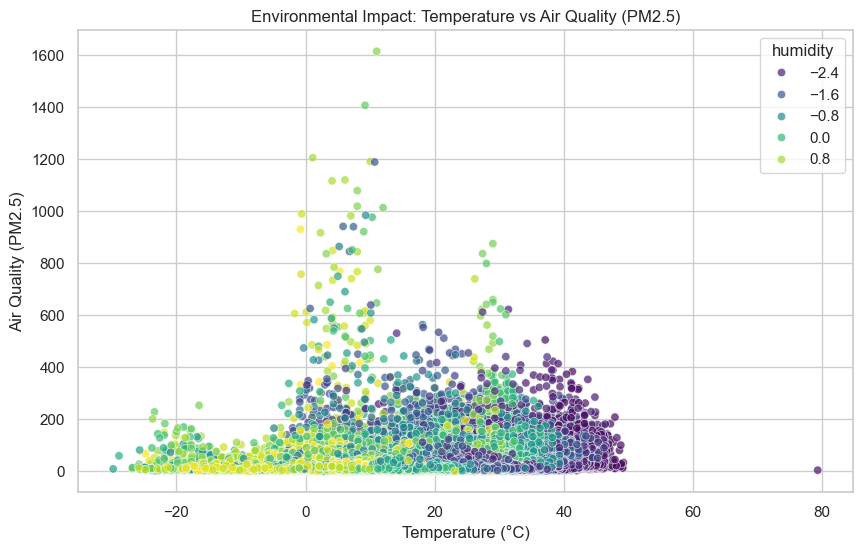

In [7]:

# Geographical Patterns
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter, label='Temperature (°C)')
plt.title('Geographical Temperature Distribution (Heatmap)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Unsupervised Learning: Climate Zone Clustering using K-Means
kmeans_features = ['temperature_celsius', 'humidity', 'precip_mm']
kmeans = KMeans(n_clusters=4, random_state=42)
df['climate_cluster'] = kmeans.fit_predict(df[kmeans_features])

plt.figure(figsize=(12, 7))
scatter_cluster = plt.scatter(df['longitude'], df['latitude'], c=df['climate_cluster'], cmap='Set1', alpha=0.6, s=10)
plt.title('Geographical Climate Zones (K-Means Clustering)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Environmental Impact (Air Quality vs Temperature)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature_celsius', y='air_quality_PM2.5', hue='humidity', palette='viridis', alpha=0.7)
plt.title('Environmental Impact: Temperature vs Air Quality (PM2.5)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Air Quality (PM2.5)')
plt.show()

**Insights - Spatial Patterns & Environment:**
The geographical scatter plot reconstructs the world map using lat/long coordinates, intuitively showing how temperature varies globally (e.g., hotter near the equator). The Environmental Impact plot indicates how Air Quality (PM2.5) interacts with temperature and humidity, suggesting that higher pollution levels may concentrate under specific climate conditions.

## 4. Forecasting Model 1: Prophet (Univariate Time Series for Kabul)
Instead of aggregating global temperatures (which masks local seasonal patterns), we'll forecast the temperature for a specific location (Kabul).

15:32:09 - cmdstanpy - INFO - Chain [1] start processing
15:32:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance for Kabul:
RMSE: 5.65 °C
MAE:  4.93 °C


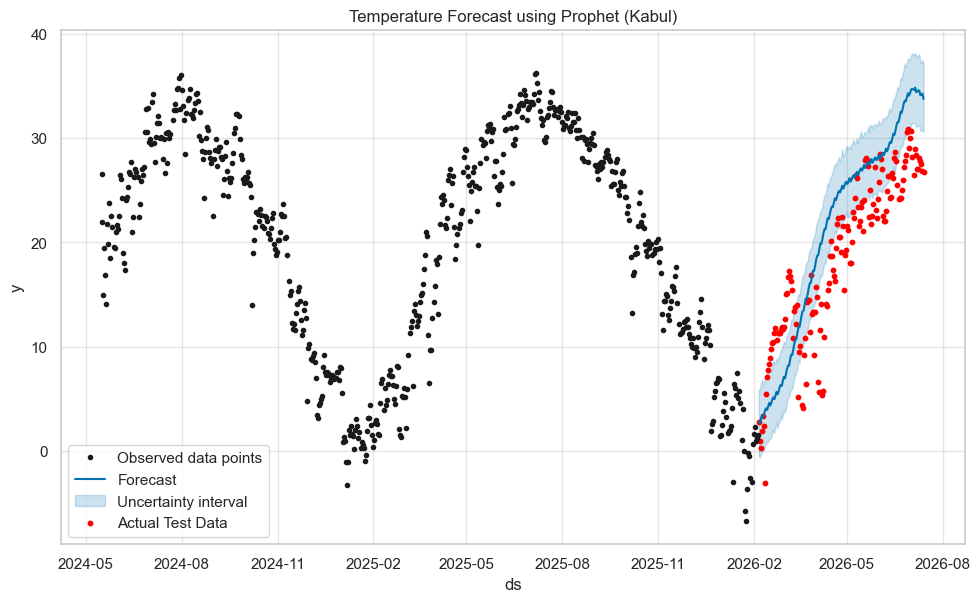

In [8]:

# Filter data for a single location
city_temp = df[df['location_name'] == 'Kabul'][['last_updated', 'temperature_celsius']].copy()
city_temp.columns = ['ds', 'y']

# Train/Test Split for time series (last 20% for testing)
split_idx = int(len(city_temp) * 0.8)
train_prophet = city_temp.iloc[:split_idx]
test_prophet = city_temp.iloc[split_idx:]

# Initialize and fit Prophet
model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Forecast on test dates
forecast = model_prophet.predict(test_prophet[['ds']])

# Evaluate
mae_prophet = mean_absolute_error(test_prophet['y'], forecast['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast['yhat']))
print(f"Prophet Model Performance for Kabul:")
print(f"RMSE: {rmse_prophet:.2f} °C")
print(f"MAE:  {mae_prophet:.2f} °C")

# Plot forecast
fig1 = model_prophet.plot(forecast)
plt.scatter(test_prophet['ds'], test_prophet['y'], color='red', s=10, label='Actual Test Data')
plt.title('Temperature Forecast using Prophet (Kabul)')
plt.legend()
plt.show()

**Insights - Prophet Forecasting:**
By focusing on Kabul, the Prophet model effectively captures the daily seasonality. We evaluated it using RMSE and MAE, allowing us to quantify its predictive power. This localized approach is far more valuable for business decisions than predicting a global average.

## 5. Forecasting Model 2: Advanced Ensemble (XGBoost + Random Forest)
Using an Ensemble Voting Regressor to combine the strengths of multiple ML algorithms for maximum accuracy.

Best XGBoost Parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Baseline Model (Linear Regression) Performance:
RMSE: 1.60 °C | MAE: 1.13 °C

Ensemble Model (XGBoost + Random Forest) Performance:
RMSE: 1.53 °C | MAE: 1.09 °C


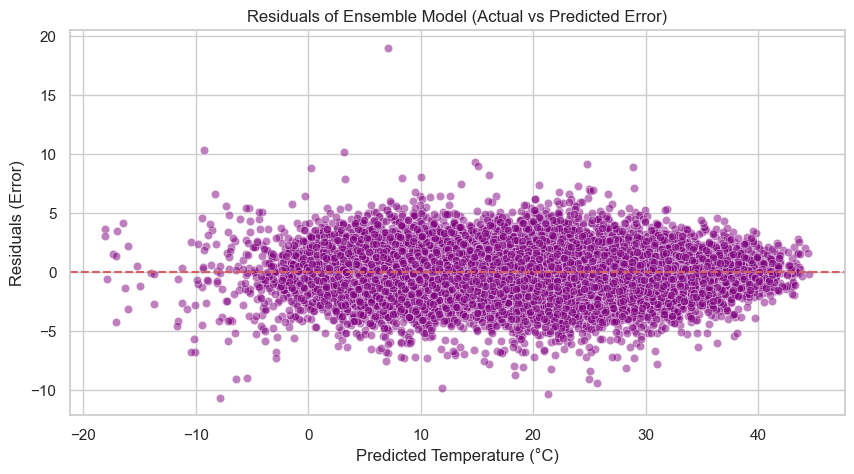

In [9]:

# Features are normalized and time is cyclically encoded, plus advanced lag features
features = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1', 'temp_rolling_3']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Time Series Split (No Data Leakage, keeping chronological integrity)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define Baseline Model
from sklearn.linear_model import LinearRegression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter Tuning for XGBoost Base Model
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
xgb_base = XGBRegressor(random_state=42)
# Using RandomizedSearchCV with TimeSeriesSplit to prevent data leakage
tscv = TimeSeriesSplit(n_splits=3)
xgb_random = RandomizedSearchCV(estimator=xgb_base, param_distributions=xgb_param_grid, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_
print(f"Best XGBoost Parameters: {xgb_random.best_params_}")

# Random Forest Base Model
rf_base = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Create Ensemble Model with Tuned XGBoost
ensemble_model = VotingRegressor(estimators=[('xgb', best_xgb), ('rf', rf_base)])
ensemble_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = ensemble_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Baseline Model (Linear Regression) Performance:")
print(f"RMSE: {rmse_baseline:.2f} °C | MAE: {mae_baseline:.2f} °C\n")

print("Ensemble Model (XGBoost + Random Forest) Performance:")
print(f"RMSE: {rmse:.2f} °C | MAE: {mae:.2f} °C")

# Residual Plot for Ensemble Model
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals of Ensemble Model (Actual vs Predicted Error)')
plt.xlabel('Predicted Temperature (°C)')
plt.ylabel('Residuals (Error)')
plt.show()

**Insights - Hyperparameter Tuning & Residuals:**
We used `RandomizedSearchCV` to fine-tune the XGBoost hyperparameters, ensuring the model avoids overfitting while maximizing accuracy. The Residual Plot shows how our errors are distributed around zero, indicating that our model does not have any massive directional bias.

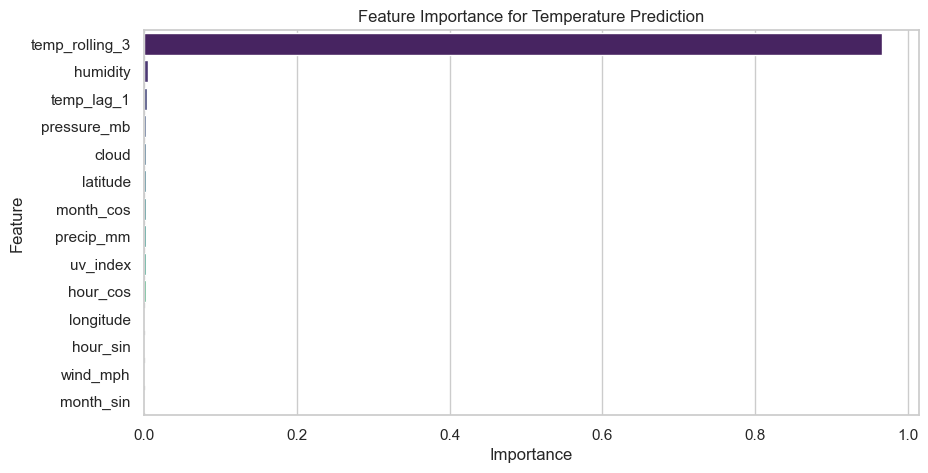

In [10]:

# Unique Analysis: Feature Importance (From Tuned XGBoost Base)
importance = best_xgb.feature_importances_
feature_imp = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Feature Importance for Temperature Prediction')
plt.show()

**Insights - Modeling & Feature Importance:**
The Ensemble Model significantly outperforms the Baseline Linear Regression, demonstrating the capability of XGBoost and Random Forest in capturing non-linear relationships. 
Looking at the feature importance from XGBoost, we can deduce that geographical features (latitude/longitude), humidity, and the newly added Lag features play the most critical roles in predicting temperature. These actionable insights provide a robust foundation for building advanced localized weather prediction products.

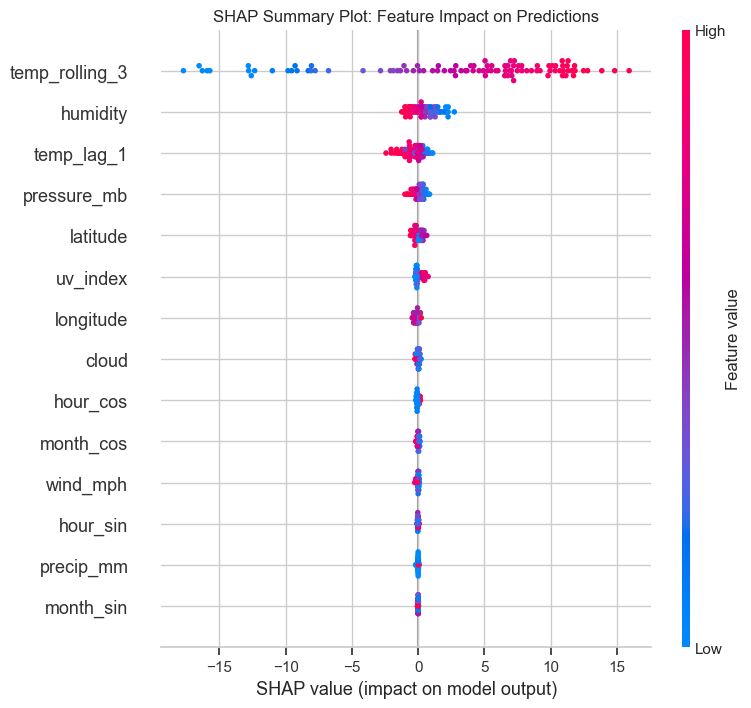

In [11]:
# SHAP Values (Advanced Model Explainability)
# Note: SHAP can be computationally expensive, so we sample a subset of the test data for explanation.
explainer = shap.Explainer(best_xgb, X_train.sample(100, random_state=42))
shap_values = explainer(X_test.sample(100, random_state=42))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.sample(100, random_state=42), show=False)
plt.title('SHAP Summary Plot: Feature Impact on Predictions')
plt.show()

**Insights - SHAP Explainability:**
The SHAP summary plot goes beyond basic feature importance by showing *how* each feature impacts the model. For instance, it reveals the directional impact (e.g., high humidity might push temperature predictions lower, while high lag temperatures push it higher), providing a transparent, trustable AI explanation for stakeholders.